In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("post natal data.csv")

print(df.head())
print(df.info())

         Timestamp    Age Feeling sad or Tearful  \
0  6/14/2022 20:02  35-40                    Yes   
1  6/14/2022 20:03  40-45                    Yes   
2  6/14/2022 20:04  35-40                    Yes   
3  6/14/2022 20:05  35-40                    Yes   
4  6/14/2022 20:06  40-45                    Yes   

  Irritable towards baby & partner Trouble sleeping at night  \
0                              Yes   Two or more days a week   
1                               No                        No   
2                               No                       Yes   
3                              Yes                       Yes   
4                               No   Two or more days a week   

  Problems concentrating or making decision Overeating or loss of appetite  \
0                                       Yes                            Yes   
1                                       Yes                            Yes   
2                                       Yes                         

In [3]:
print(df.isnull().sum())

df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

Timestamp                                     0
Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64


In [4]:
target = "target_column_name"  # change this

In [5]:
print(df.columns)

Index(['Timestamp', 'Age', 'Feeling sad or Tearful',
       'Irritable towards baby & partner', 'Trouble sleeping at night',
       'Problems concentrating or making decision',
       'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
       'Problems of bonding with baby', 'Suicide attempt'],
      dtype='object')


In [6]:
target = "Postpartum_Depression"

In [7]:
if target in df.columns:
    X = df.drop(columns=[target])
    y = df[target]
else:
    print("Target column not found. Available columns are:")
    print(df.columns)

Target column not found. Available columns are:
Index(['Timestamp', 'Age', 'Feeling sad or Tearful',
       'Irritable towards baby & partner', 'Trouble sleeping at night',
       'Problems concentrating or making decision',
       'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
       'Problems of bonding with baby', 'Suicide attempt'],
      dtype='object')


In [8]:
target = "YOUR_TARGET_COLUMN_NAME"

In [9]:
target = "Depression"

In [10]:
if "Depression" in df.columns:   # replace with actual name later
    target = "Depression"
else:
    print("Target not found. Available columns:")
    print(df.columns)

Target not found. Available columns:
Index(['Timestamp', 'Age', 'Feeling sad or Tearful',
       'Irritable towards baby & partner', 'Trouble sleeping at night',
       'Problems concentrating or making decision',
       'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
       'Problems of bonding with baby', 'Suicide attempt'],
      dtype='object')


In [11]:
df.head()

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [12]:
df.columns

Index(['Timestamp', 'Age', 'Feeling sad or Tearful',
       'Irritable towards baby & partner', 'Trouble sleeping at night',
       'Problems concentrating or making decision',
       'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
       'Problems of bonding with baby', 'Suicide attempt'],
      dtype='object')

In [13]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Timestamp                                  1503 non-null   object
 1   Age                                        1503 non-null   object
 2   Feeling sad or Tearful                     1503 non-null   object
 3   Irritable towards baby & partner           1503 non-null   object
 4   Trouble sleeping at night                  1503 non-null   object
 5   Problems concentrating or making decision  1503 non-null   object
 6   Overeating or loss of appetite             1503 non-null   object
 7   Feeling anxious                            1503 non-null   object
 8   Feeling of guilt                           1503 non-null   object
 9   Problems of bonding with baby              1503 non-null   object
 10  Suicide attempt                     

In [14]:
df.nunique()

Timestamp                                    90
Age                                           5
Feeling sad or Tearful                        3
Irritable towards baby & partner              3
Trouble sleeping at night                     3
Problems concentrating or making decision     3
Overeating or loss of appetite                3
Feeling anxious                               2
Feeling of guilt                              3
Problems of bonding with baby                 3
Suicide attempt                               3
dtype: int64

In [15]:
target = "ACTUAL_COLUMN_NAME"

In [16]:
for col in df.columns:
    if df[col].nunique() <= 5:
        print("Possible target:", col)

Possible target: Age
Possible target: Feeling sad or Tearful
Possible target: Irritable towards baby & partner
Possible target: Trouble sleeping at night
Possible target: Problems concentrating or making decision
Possible target: Overeating or loss of appetite
Possible target: Feeling anxious
Possible target: Feeling of guilt
Possible target: Problems of bonding with baby
Possible target: Suicide attempt


In [17]:
print(df.columns.tolist())

['Timestamp', 'Age', 'Feeling sad or Tearful', 'Irritable towards baby & partner', 'Trouble sleeping at night', 'Problems concentrating or making decision', 'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt', 'Problems of bonding with baby', 'Suicide attempt']


In [18]:
for col in df.columns:
    print("\nCOLUMN:", col)
    print(df[col].value_counts().head())


COLUMN: Timestamp
Timestamp
6/15/2022 22:24    51
6/14/2022 22:19    43
6/15/2022 0:31     35
6/15/2022 0:27     35
6/15/2022 0:28     35
Name: count, dtype: int64

COLUMN: Age
Age
40-45    364
35-40    349
30-35    338
45-50    271
25-30    181
Name: count, dtype: int64

COLUMN: Feeling sad or Tearful
Feeling sad or Tearful
Yes          536
No           524
Sometimes    443
Name: count, dtype: int64

COLUMN: Irritable towards baby & partner
Irritable towards baby & partner
Yes          561
No           499
Sometimes    443
Name: count, dtype: int64

COLUMN: Trouble sleeping at night
Trouble sleeping at night
Two or more days a week    640
Yes                        445
No                         418
Name: count, dtype: int64

COLUMN: Problems concentrating or making decision
Problems concentrating or making decision
No       595
Often    473
Yes      435
Name: count, dtype: int64

COLUMN: Overeating or loss of appetite
Overeating or loss of appetite
No            841
Yes           34

In [19]:
target = "Depression"

In [20]:
"Mental_Health_Status"

'Mental_Health_Status'

In [21]:
symptom_cols = [
    "Feeling sad or Tearful",
    "Irritable towards baby & partner",
    "Trouble sleeping at night",
    "Problems concentrating or making decision",
    "Overeating or loss of appetite",
    "Feeling anxious",
    "Feeling of guilt",
    "Problems of bonding with baby",
    "Suicide attempt"
]

In [22]:
for col in symptom_cols:
    df[col] = df[col].astype(str).apply(lambda x: 1 if "yes" in x.lower() else 0)

In [23]:
df["Risk"] = df[symptom_cols].sum(axis=1)

In [24]:
df["Risk"] = df["Risk"].apply(lambda x: 1 if x >= 4 else 0)

In [25]:
target = "Risk"

X = df.drop(columns=[target, "Timestamp", "Age"])
y = df[target]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.preprocessing import LabelEncoder

for col in X.columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9933554817275747
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       200
           1       0.98      1.00      0.99       101

    accuracy                           0.99       301
   macro avg       0.99      0.99      0.99       301
weighted avg       0.99      0.99      0.99       301



In [30]:

print(y.value_counts())

Risk
0    1000
1     503
Name: count, dtype: int64


In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",   # 🔥 FIX IMBALANCE HERE
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [32]:
print(y.value_counts())

Risk
0    1000
1     503
Name: count, dtype: int64


In [33]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9933554817275747
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       200
           1       0.98      1.00      0.99       101

    accuracy                           0.99       301
   macro avg       0.99      0.99      0.99       301
weighted avg       0.99      0.99      0.99       301



In [34]:
y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 1.0


In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,        # more trees = better learning
    max_depth=10,            # prevents overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.973421926910299

Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98       200
           1       0.93      0.99      0.96       101

    accuracy                           0.97       301
   macro avg       0.96      0.98      0.97       301
weighted avg       0.97      0.97      0.97       301



In [37]:
import pandas as pd

importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_df)

                                     Feature  Importance
3  Problems concentrating or making decision    0.211503
2                  Trouble sleeping at night    0.156250
8                            Suicide attempt    0.149837
7              Problems of bonding with baby    0.127928
0                     Feeling sad or Tearful    0.094648
1           Irritable towards baby & partner    0.077654
6                           Feeling of guilt    0.071970
4             Overeating or loss of appetite    0.070838
5                            Feeling anxious    0.039373


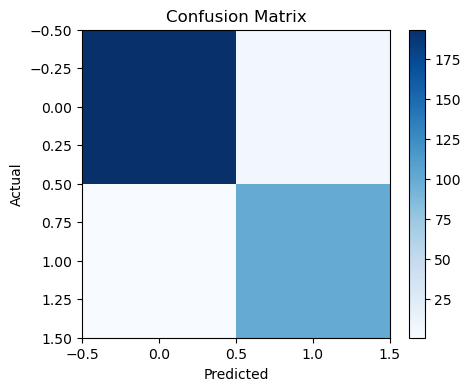

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [39]:
risk_score = model.predict_proba(X_test)[:, 1] * 100

print("Sample Risk Scores:", risk_score[:10])

Sample Risk Scores: [ 98.56418222 100.          97.03508534  25.54819951  99.94200444
   0.81134945   3.60291597   0.20179077  10.80857219  32.86363682]


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
dt = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Random Forest Accuracy: 0.9933554817275747
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 0.9568106312292359


In [42]:
from sklearn.metrics import roc_auc_score

rf_prob = rf.predict_proba(X_test)[:, 1]
lr_prob = lr.predict_proba(X_test)[:, 1]
dt_prob = dt.predict_proba(X_test)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("LR ROC-AUC:", roc_auc_score(y_test, lr_prob))
print("DT ROC-AUC:", roc_auc_score(y_test, dt_prob))

RF ROC-AUC: 1.0
LR ROC-AUC: 1.0
DT ROC-AUC: 0.9879455445544555


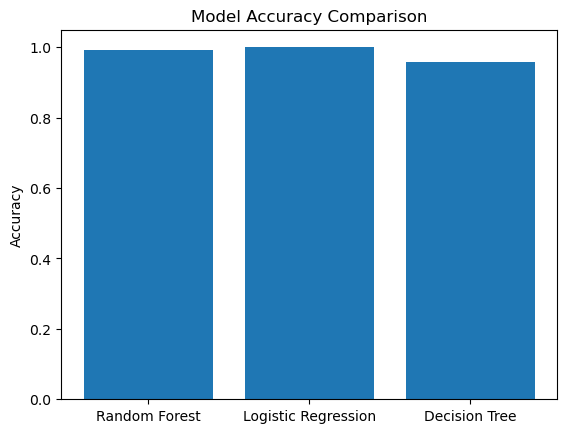

In [43]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression", "Decision Tree"]
accuracies = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred)
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [44]:
best_model = max(
    [("RF", rf), ("LR", lr), ("DT", dt)],
    key=lambda x: accuracy_score(y_test, x[1].predict(X_test))
)

print("Best Model:", best_model[0])

Best Model: LR


In [45]:
import joblib

joblib.dump(model, "postnatal_model.pkl")

['postnatal_model.pkl']

In [46]:
import json

feature_list = list(X.columns)

with open("features.json", "w") as f:
    json.dump(feature_list, f)